In [1]:

# ── CELL 1 ── Install / import libraries ─────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import (MobileNetV2, VGG16, ResNet50)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc)
from sklearn.preprocessing import label_binarize

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.17.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ── CELL 2 ── Configuration ──────────────────────────────────

DATASET_DIR   = '/kaggle/input/freshness-fish-dataset/Freshness Fish Dataset'
IMG_HEIGHT    = 224
IMG_WIDTH     = 224
BATCH_SIZE    = 32
EPOCHS        = 30
LEARNING_RATE = 1e-4
SEED          = 42
OUTPUT_DIR    = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)


Dataset contents:
Classes found: ['C1', 'C2', 'C3']
  C1: 400 images
  C2: 400 images
  C3: 400 images

Total images: 1200


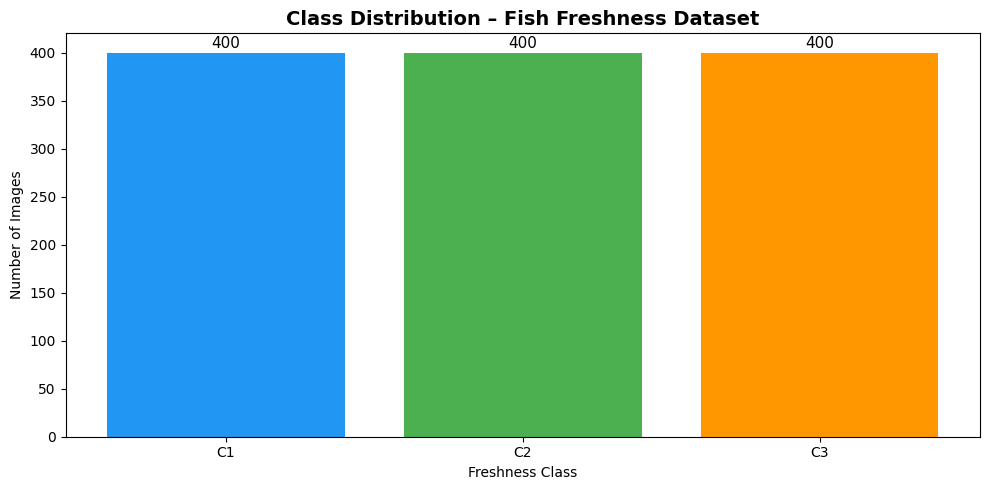

In [3]:
# ── CELL 3 ── Explore dataset structure ─────────────────────
print("Dataset contents:")
class_names = sorted(os.listdir(DATASET_DIR))
print("Classes found:", class_names)

counts = {}
for cls in class_names:
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.isdir(cls_path):
        n = len([f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        counts[cls] = n
        print(f"  {cls}: {n} images")
print(f"\nTotal images: {sum(counts.values())}")

# Class distribution bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(counts.keys(), counts.values(),
               color=['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0'][:len(counts)])
plt.title('Class Distribution – Fish Freshness Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Freshness Class')
plt.ylabel('Number of Images')
for bar, val in zip(bars, counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_distribution.png', dpi=150)
plt.show()


In [4]:
# ── CELL 4 ── Data generators (train / val / test) ──────────
# Using ImageDataGenerator for augmentation on training set
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    validation_split   = 0.2,        # 20 % → val
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    shear_range        = 0.1,
    zoom_range         = 0.2,
    horizontal_flip    = True,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'nearest'
)

# Validation / test: only rescale
val_test_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size  = (IMG_HEIGHT, IMG_WIDTH),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    seed         = SEED,
    shuffle      = True
)

val_gen = val_test_datagen.flow_from_directory(
    DATASET_DIR,
    target_size  = (IMG_HEIGHT, IMG_WIDTH),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    seed         = SEED,
    shuffle      = False
)

NUM_CLASSES  = len(train_gen.class_indices)
CLASS_LABELS = list(train_gen.class_indices.keys())
print(f"\nClasses ({NUM_CLASSES}):", CLASS_LABELS)
print("Training samples  :", train_gen.samples)
print("Validation samples:", val_gen.samples)


Found 960 images belonging to 3 classes.
Found 240 images belonging to 3 classes.

Classes (3): ['C1', 'C2', 'C3']
Training samples  : 960
Validation samples: 240


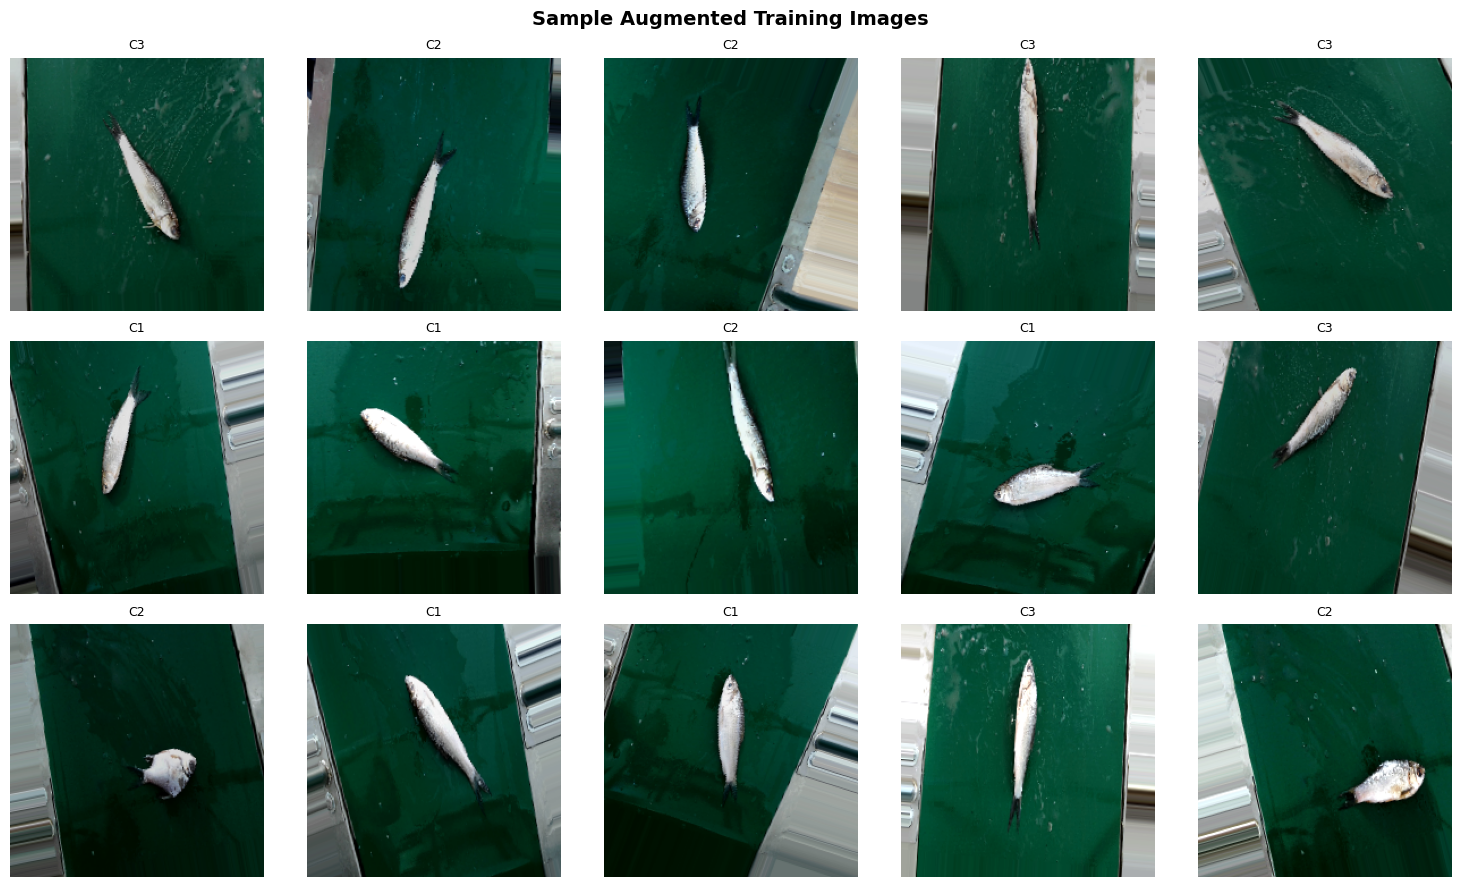

In [5]:
# ── CELL 5 ── Visualise augmented samples ───────────────────
images, labels = next(train_gen)
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(CLASS_LABELS[np.argmax(labels[i])], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Augmented Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_images.png', dpi=150)
plt.show()

In [6]:
# ── CELL 6 ── Custom CNN model ───────────────────────────────
def build_custom_cnn(num_classes, input_shape=(224, 224, 3)):
    """
    A five-block custom CNN designed for fish freshness classification.
    Blocks progressively increase filters: 32→64→128→256→512.
    """
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Block 5
    x = layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Head
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='FishFreshnessCNN')
    return model

cnn_model = build_custom_cnn(NUM_CLASSES)
cnn_model.summary()

cnn_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)


Model: "FishFreshnessCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 2,161,955 (8.25 MB)

 Trainable params: 2,159,523 (8.24 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [7]:
# ── CELL 7 ── Callbacks ──────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(f'{OUTPUT_DIR}/best_cnn_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [8]:
# ── CELL 8 ── Train custom CNN ───────────────────────────────
print("\n" + "="*55)
print("  TRAINING CUSTOM CNN MODEL")
print("="*55)
cnn_history = cnn_model.fit(
    train_gen,
    epochs            = EPOCHS,
    validation_data   = val_gen,
    callbacks         = callbacks,
    verbose           = 1
)


  TRAINING CUSTOM CNN MODEL
Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.4670 - loss: 1.0002
Epoch 1: val_accuracy improved from -inf to 0.33333, saving model to /kaggle/working/outputs/best_cnn_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.4702 - loss: 0.9975 - val_accuracy: 0.3333 - val_loss: 1.1278 - learning_rate: 1.0000e-04
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.7575 - loss: 0.6397
Epoch 2: val_accuracy did not improve from 0.33333
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 917ms/step - accuracy: 0.7580 - loss: 0.6378 - val_accuracy: 0.3333 - val_loss: 1.2014 - learning_rate: 1.0000e-04
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.8387 - loss: 0.4278
Epoch 3: val_accuracy did not improve from 0.33333
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 847ms/step - accuracy: 0.8392 - loss: 0.4268 - val_accuracy: 0.3333 - val_loss: 1.8247 - learning_rate: 1.0000e-04
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy

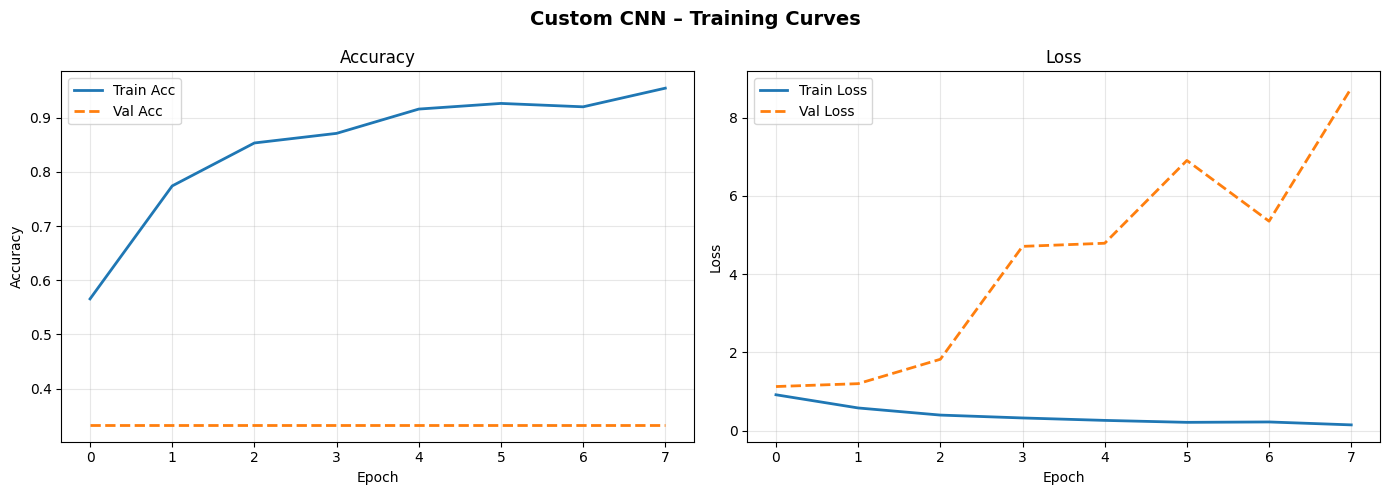

'/kaggle/working/outputs/custom_cnn_curves.png'

In [9]:
# ── CELL 9 ── Helper: plot training curves ───────────────────
def plot_history(history, model_name, output_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} – Training Curves', fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Acc',  linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',    linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],         label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'],     label='Val Loss',   linewidth=2, linestyle='--')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = f'{output_dir}/{model_name.lower().replace(" ", "_")}_curves.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    return fname

plot_history(cnn_history, 'Custom CNN', OUTPUT_DIR)


Custom CNN  →  Val Loss: 1.1278 | Val Accuracy: 0.3333

Classification Report – Custom CNN:
              precision    recall  f1-score   support

          C1       0.00      0.00      0.00        80
          C2       0.33      1.00      0.50        80
          C3       0.00      0.00      0.00        80

    accuracy                           0.33       240
   macro avg       0.11      0.33      0.17       240
weighted avg       0.11      0.33      0.17       240



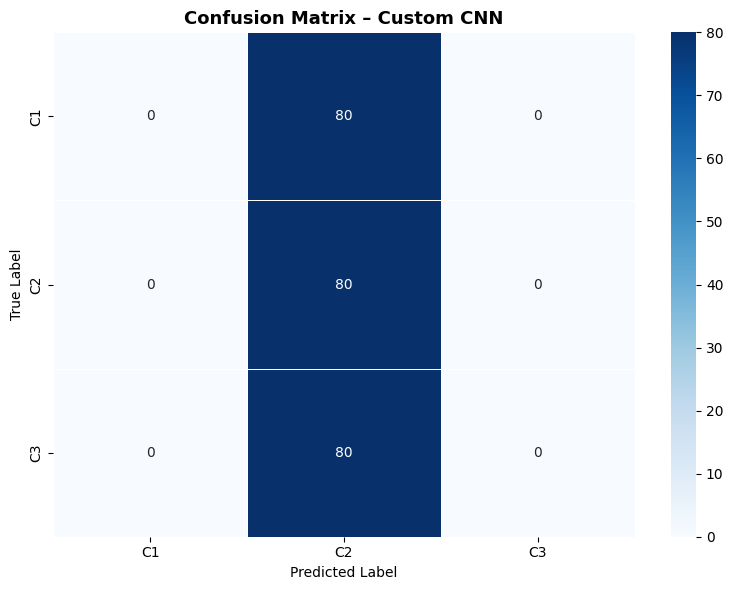

In [10]:
# ── CELL 10 ── Evaluate custom CNN ──────────────────────────
def evaluate_model(model, gen, class_labels, model_name, output_dir):
    """Full evaluation: loss/acc, confusion matrix, classification report."""
    loss, acc = model.evaluate(gen, verbose=0)
    print(f"\n{model_name}  →  Val Loss: {loss:.4f} | Val Accuracy: {acc:.4f}")

    gen.reset()
    y_pred_probs = model.predict(gen, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    y_true       = gen.classes

    # Classification report
    report = classification_report(y_true, y_pred, target_names=class_labels)
    print(f"\nClassification Report – {model_name}:\n{report}")

    report_df = pd.DataFrame(
        classification_report(y_true, y_pred, target_names=class_labels,
                              output_dict=True)
    ).transpose()
    report_df.to_csv(f'{output_dir}/{model_name.lower().replace(" ", "_")}_report.csv')

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES-1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5)
    plt.title(f'Confusion Matrix – {model_name}', fontsize=13, fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    cm_path = f'{output_dir}/{model_name.lower().replace(" ", "_")}_confusion_matrix.png'
    plt.savefig(cm_path, dpi=150)
    plt.show()

    return loss, acc, y_true, y_pred_probs

cnn_loss, cnn_acc, cnn_y_true, cnn_y_probs = evaluate_model(
    cnn_model, val_gen, CLASS_LABELS, 'Custom CNN', OUTPUT_DIR
)


  TRAINING MobileNetV2 (Feature Extraction)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.3750 - loss: 1.2242
Epoch 1: val_accuracy improved from -inf to 0.56667, saving model to /kaggle/working/outputs/best_mv2_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.3789 - loss: 1.2181 - val_accuracy: 0.5667 - val_loss: 0.9426 - learning_rate: 1.0000e-04
Epoch 2/30
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.6188 - loss: 0.8295
Epoch 2: val_accuracy improved from 0.56667 to 0.64583, saving model to /kaggle/working/outputs/best_mv2_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 957ms/step - accuracy: 0.6208 - loss: 0.8273 - val_accuracy: 0.6458 - val_loss: 0.8480 - learning_rate: 1.0000e-04
Epoch 3/30
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.7280 - loss: 0.6716
Epoch 3: val_accuracy did not improve from 0.64583
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 863ms/step - accuracy: 0.7292 - loss: 0.6691 -

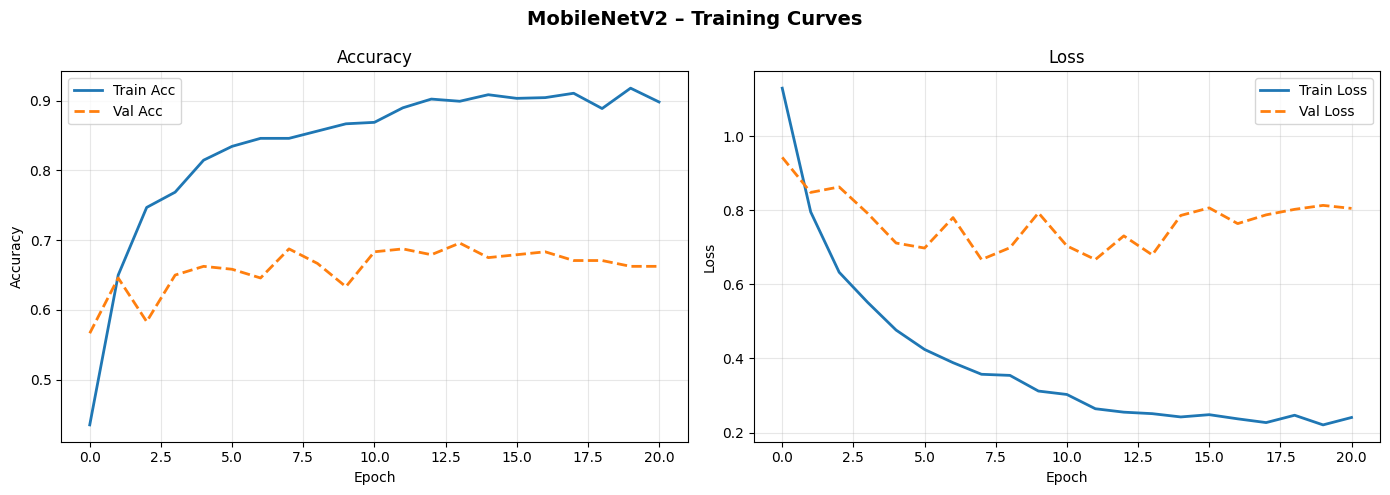


MobileNetV2  →  Val Loss: 0.6794 | Val Accuracy: 0.6958

Classification Report – MobileNetV2:
              precision    recall  f1-score   support

          C1       1.00      0.93      0.96        80
          C2       0.53      0.99      0.69        80
          C3       0.88      0.17      0.29        80

    accuracy                           0.70       240
   macro avg       0.80      0.70      0.65       240
weighted avg       0.80      0.70      0.65       240



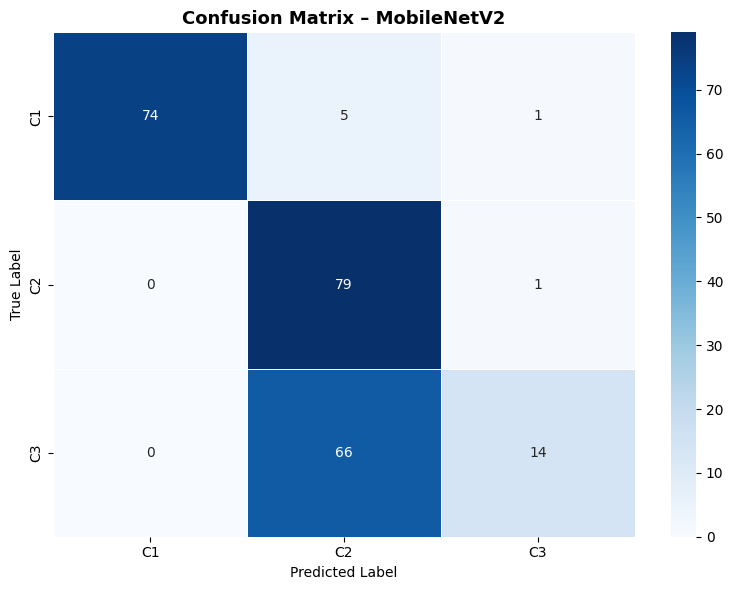


  FINE-TUNING MobileNetV2
Epoch 1/20
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.3564 - loss: 1.2585
Epoch 1: val_accuracy did not improve from 0.69583
30/30 ━━━━━━━━━━━━━━━━━━━━ 55s 964ms/step - accuracy: 0.3572 - loss: 1.2556 - val_accuracy: 0.4083 - val_loss: 1.0994 - learning_rate: 1.0000e-05
Epoch 2/20
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.3964 - loss: 1.1158
Epoch 2: val_accuracy did not improve from 0.69583
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 829ms/step - accuracy: 0.3989 - loss: 1.1136 - val_accuracy: 0.4750 - val_loss: 1.0588 - learning_rate: 1.0000e-05
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.4904 - loss: 1.0338
Epoch 3: val_accuracy did not improve from 0.69583
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 962ms/step - accuracy: 0.4910 - loss: 1.0330 - val_accuracy: 0.5042 - val_loss: 1.0212 - learning_rate: 1.0000e-05
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.5928 - loss: 0.8767
Epoch 4: val_accuracy did not improve 

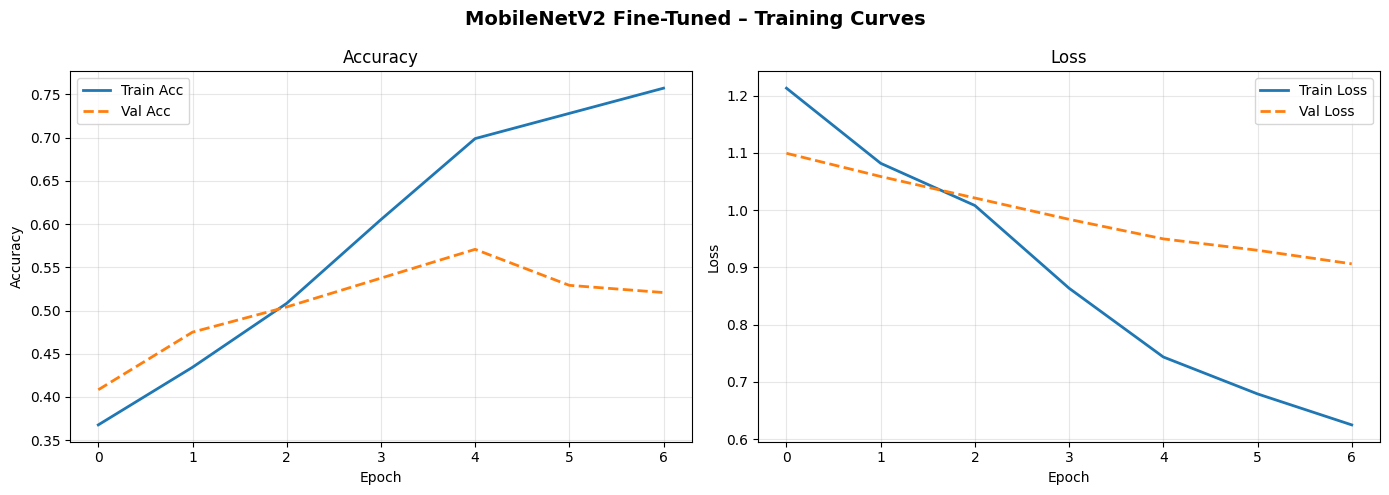


MobileNetV2_FineTuned  →  Val Loss: 1.0994 | Val Accuracy: 0.4083

Classification Report – MobileNetV2_FineTuned:
              precision    recall  f1-score   support

          C1       0.35      0.31      0.33        80
          C2       0.44      0.65      0.52        80
          C3       0.43      0.26      0.33        80

    accuracy                           0.41       240
   macro avg       0.40      0.41      0.39       240
weighted avg       0.40      0.41      0.39       240



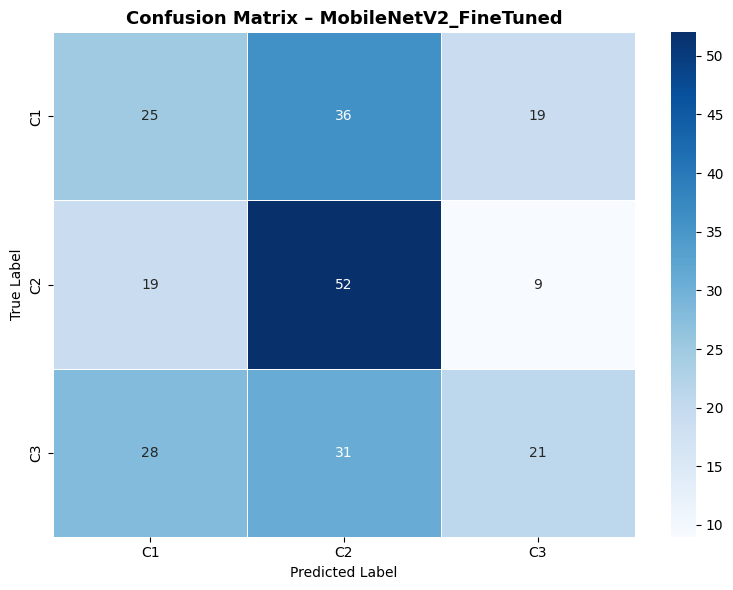

In [11]:
# ── CELL 11 ── Transfer Learning: MobileNetV2 ───────────────
def build_transfer_model(base_app, num_classes, model_name,
                         input_shape=(224, 224, 3), fine_tune_at=None):
    """
    Build a transfer learning model.
    fine_tune_at=None  → feature extraction only (frozen base).
    fine_tune_at=int   → unfreeze layers from that index onward.
    """
    base = base_app(weights='imagenet', include_top=False,
                    input_shape=input_shape)
    base.trainable = False

    if fine_tune_at is not None:
        base.trainable = True
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name=model_name)
    return model

# ── MobileNetV2 (feature extraction) ────────────────────────
print("\n" + "="*55)
print("  TRAINING MobileNetV2 (Feature Extraction)")
print("="*55)
mv2_model = build_transfer_model(MobileNetV2, NUM_CLASSES, 'MobileNetV2')
mv2_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
mv2_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(f'{OUTPUT_DIR}/best_mv2_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]
mv2_history = mv2_model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=mv2_callbacks, verbose=1
)
plot_history(mv2_history, 'MobileNetV2', OUTPUT_DIR)
mv2_loss, mv2_acc, mv2_y_true, mv2_y_probs = evaluate_model(
    mv2_model, val_gen, CLASS_LABELS, 'MobileNetV2', OUTPUT_DIR
)

# ── Fine-tune MobileNetV2 ────────────────────────────────────
print("\n" + "="*55)
print("  FINE-TUNING MobileNetV2")
print("="*55)
mv2_ft_model = build_transfer_model(
    MobileNetV2, NUM_CLASSES, 'MobileNetV2_FineTuned', fine_tune_at=100
)
mv2_ft_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
mv2_ft_history = mv2_ft_model.fit(
    train_gen, epochs=20,
    validation_data=val_gen,
    callbacks=mv2_callbacks, verbose=1
)
plot_history(mv2_ft_history, 'MobileNetV2 Fine-Tuned', OUTPUT_DIR)
mv2_ft_loss, mv2_ft_acc, _, mv2_ft_probs = evaluate_model(
    mv2_ft_model, val_gen, CLASS_LABELS, 'MobileNetV2_FineTuned', OUTPUT_DIR
)


  TRAINING VGG16 (Feature Extraction)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.3251 - loss: 1.1771
Epoch 1: val_accuracy improved from -inf to 0.56250, saving model to /kaggle/working/outputs/best_vgg_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.3254 - loss: 1.1765 - val_accuracy: 0.5625 - val_loss: 1.0902 - learning_rate: 1.0000e-04
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.3743 - loss: 1.1242
Epoch 2: val_accuracy improved from 0.56250 to 0.56667, saving model to /kaggle/working/outputs/best_vgg_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 905ms/step - accuracy: 0.3744 - loss: 1.1241 - val_accuracy: 0.5667 - val_loss: 1.0723 - learning_rate: 1.0000e-04
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.3730 - loss: 1.1159
Epoch 3: val_accuracy did not improve from 0.56667
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 853ms/step - accuracy: 0.3736 - loss: 1.1153 - val

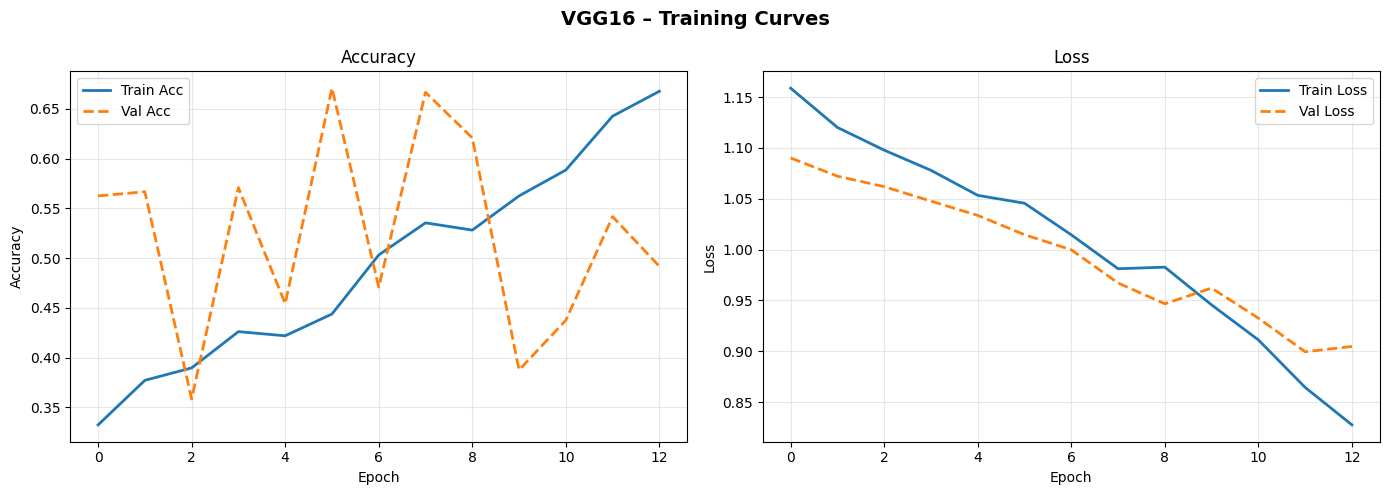


VGG16  →  Val Loss: 1.0147 | Val Accuracy: 0.6708

Classification Report – VGG16:
              precision    recall  f1-score   support

          C1       0.61      0.54      0.57        80
          C2       0.84      0.94      0.89        80
          C3       0.53      0.54      0.53        80

    accuracy                           0.67       240
   macro avg       0.66      0.67      0.67       240
weighted avg       0.66      0.67      0.67       240



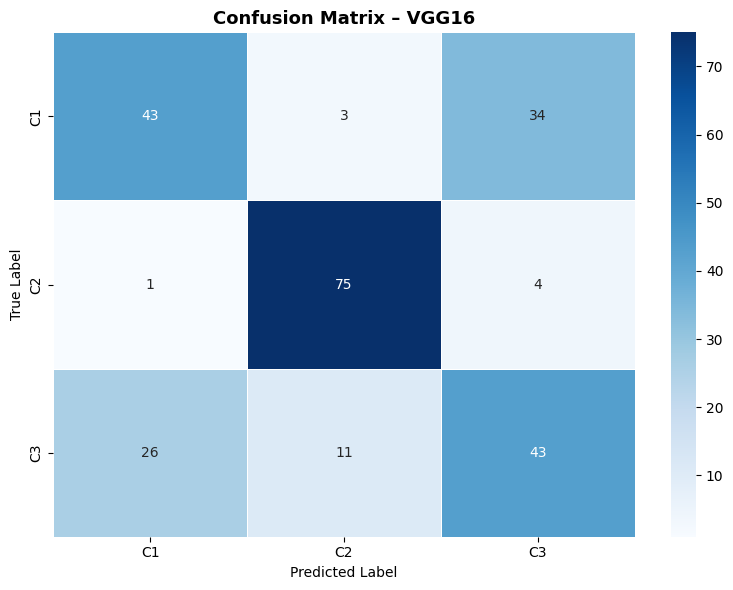

In [12]:
# ── CELL 12 ── Transfer Learning: VGG16 ─────────────────────
print("\n" + "="*55)
print("  TRAINING VGG16 (Feature Extraction)")
print("="*55)
vgg_model = build_transfer_model(VGG16, NUM_CLASSES, 'VGG16')
vgg_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
vgg_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=3, verbose=1),
    ModelCheckpoint(f'{OUTPUT_DIR}/best_vgg_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]
vgg_history = vgg_model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=vgg_callbacks, verbose=1
)
plot_history(vgg_history, 'VGG16', OUTPUT_DIR)
vgg_loss, vgg_acc, _, vgg_y_probs = evaluate_model(
    vgg_model, val_gen, CLASS_LABELS, 'VGG16', OUTPUT_DIR
)


Model Comparison:

                 Model  Val Accuracy  Val Loss  Val Accuracy (%)
           MobileNetV2      0.695833  0.679387             69.58
                 VGG16      0.670833  1.014669             67.08
MobileNetV2 Fine-Tuned      0.408333  1.099359             40.83
            Custom CNN      0.333333  1.127836             33.33


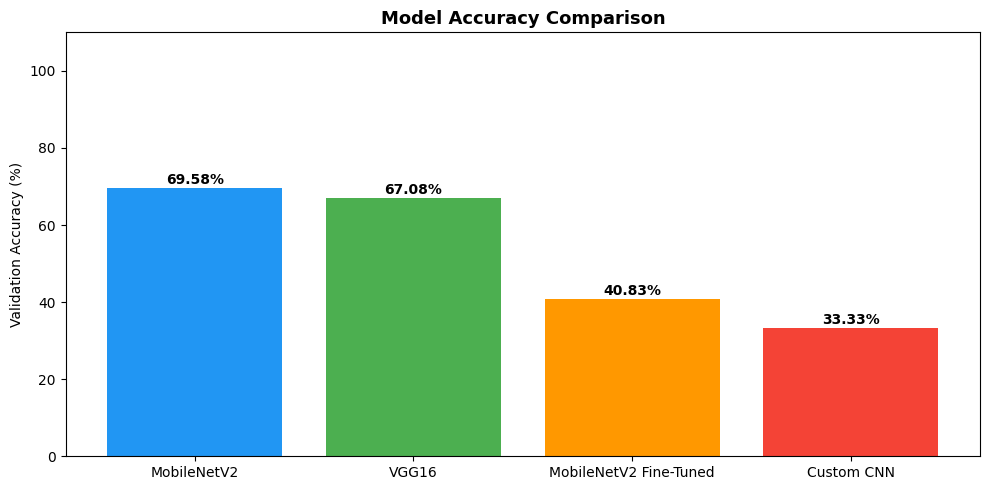

In [13]:
# ── CELL 13 ── Model comparison table ────────────────────────
results = {
    'Model': ['Custom CNN', 'MobileNetV2', 'MobileNetV2 Fine-Tuned', 'VGG16'],
    'Val Accuracy': [cnn_acc, mv2_acc, mv2_ft_acc, vgg_acc],
    'Val Loss':     [cnn_loss, mv2_loss, mv2_ft_loss, vgg_loss],
}
results_df = pd.DataFrame(results)
results_df['Val Accuracy (%)'] = (results_df['Val Accuracy'] * 100).round(2)
results_df = results_df.sort_values('Val Accuracy', ascending=False)
print("\nModel Comparison:\n")
print(results_df.to_string(index=False))
results_df.to_csv(f'{OUTPUT_DIR}/model_comparison.csv', index=False)

# Bar chart comparison
plt.figure(figsize=(10, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
bars = plt.bar(results_df['Model'], results_df['Val Accuracy (%)'],
               color=colors[:len(results_df)])
plt.title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Validation Accuracy (%)'); plt.ylim(0, 110)
for bar, val in zip(bars, results_df['Val Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_comparison.png', dpi=150)
plt.show()

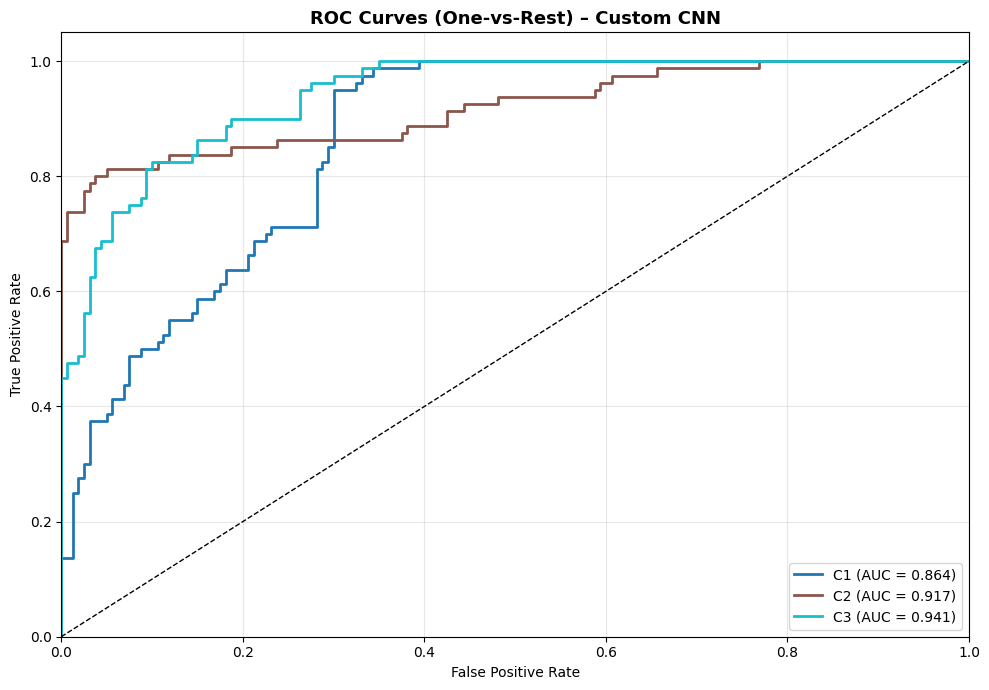

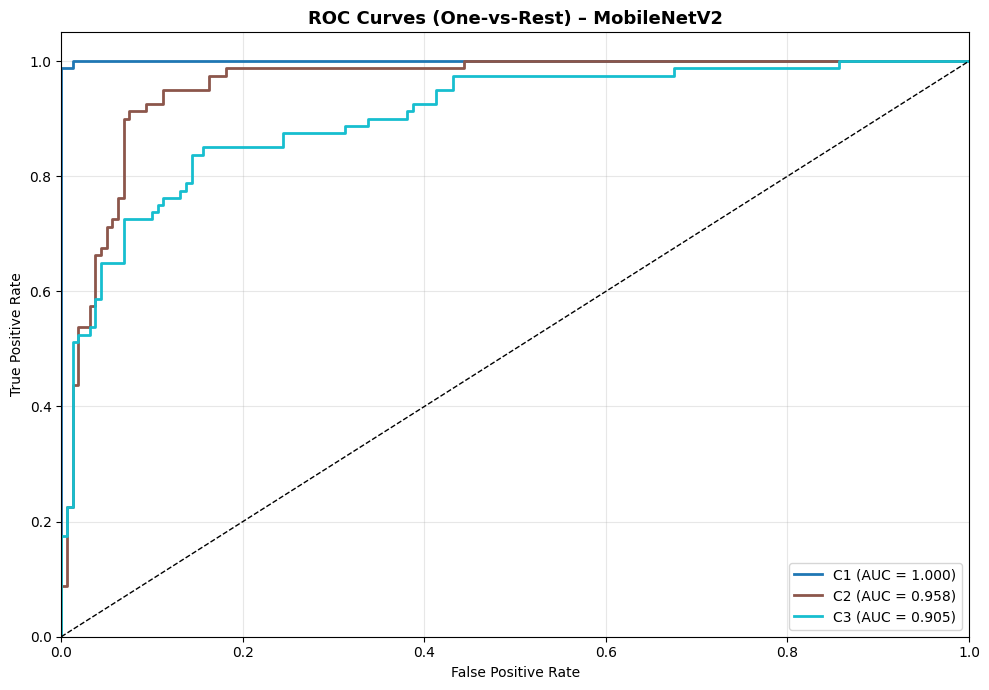

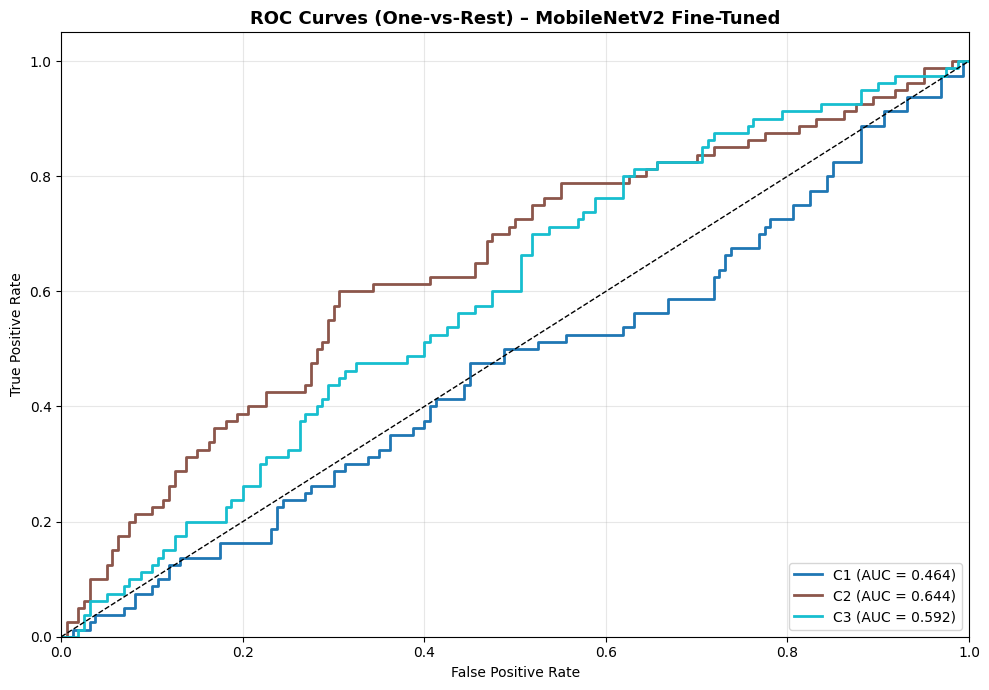

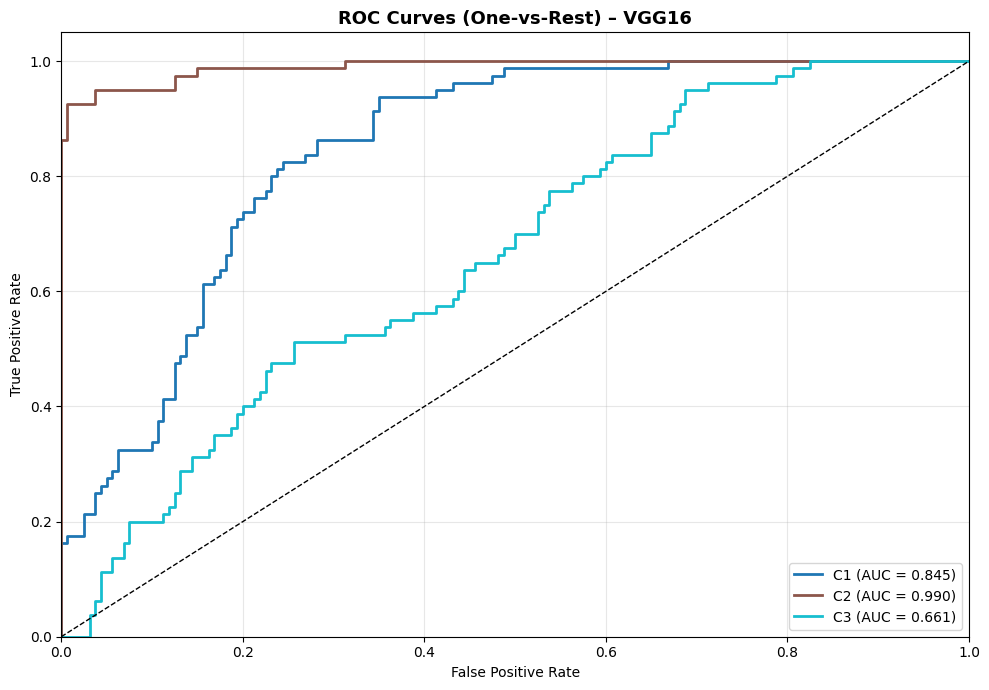

In [14]:
# ── CELL 14 ── ROC Curves (One-vs-Rest) ─────────────────────
def plot_roc_curves(y_true, y_probs, class_labels, model_name, output_dir):
    n_classes  = len(class_labels)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    plt.figure(figsize=(10, 7))
    colors = cm.tab10(np.linspace(0, 1, n_classes))

    for i, (cls, col) in enumerate(zip(class_labels, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc     = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=col, lw=2,
                 label=f'{cls} (AUC = {roc_auc:.3f})')

    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlim([0,1]); plt.ylim([0,1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves (One-vs-Rest) – {model_name}',
              fontsize=13, fontweight='bold')
    plt.legend(loc='lower right'); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/{model_name.lower().replace(" ","_")}_roc.png', dpi=150)
    plt.show()

plot_roc_curves(cnn_y_true,  cnn_y_probs,    CLASS_LABELS, 'Custom CNN',   OUTPUT_DIR)
plot_roc_curves(mv2_y_true,  mv2_y_probs,    CLASS_LABELS, 'MobileNetV2',  OUTPUT_DIR)
plot_roc_curves(mv2_y_true,  mv2_ft_probs,   CLASS_LABELS, 'MobileNetV2 Fine-Tuned', OUTPUT_DIR)
plot_roc_curves(mv2_y_true,  vgg_y_probs,    CLASS_LABELS, 'VGG16',        OUTPUT_DIR)

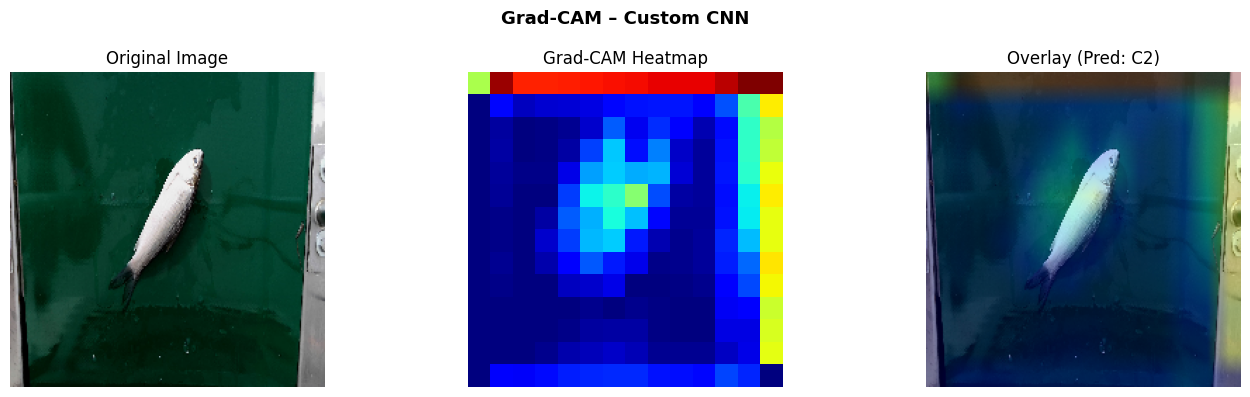

Grad-CAM for MobileNetV2 skipped: No such layer: Conv_1. Existing layers are: ['input_layer_2', 'mobilenetv2_1.00_224', 'global_average_pooling2d_1', 'dense_3', 'dropout_6', 'dense_4', 'dropout_7', 'dense_5'].


In [15]:
# ── CELL 15 ── Grad-CAM visualisation ────────────────────────
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    """Generate Grad-CAM heatmap for the given image."""
    grad_model = Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads   = tape.gradient(class_channel, conv_outputs)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(model, img_array_orig, img_array_norm,
                    last_conv_layer_name, class_labels, model_name, output_dir):
    heatmap = get_gradcam_heatmap(model, img_array_norm, last_conv_layer_name)
    heatmap_resized = np.uint8(255 * heatmap)
    heatmap_color   = cm.jet(heatmap_resized)[:, :, :3]
    heatmap_color   = tf.image.resize(heatmap_color,
                                      (IMG_HEIGHT, IMG_WIDTH)).numpy()
    superimposed    = heatmap_color * 0.4 + img_array_orig[0]
    superimposed    = np.clip(superimposed / superimposed.max(), 0, 1)

    pred_probs = model.predict(img_array_norm, verbose=0)[0]
    pred_class = class_labels[np.argmax(pred_probs)]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img_array_orig[0]); axes[0].set_title('Original Image')
    axes[1].imshow(heatmap, cmap='jet'); axes[1].set_title('Grad-CAM Heatmap')
    axes[2].imshow(superimposed);       axes[2].set_title(f'Overlay (Pred: {pred_class})')
    for ax in axes: ax.axis('off')
    plt.suptitle(f'Grad-CAM – {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/gradcam_{model_name.lower().replace(" ","_")}.png', dpi=150)
    plt.show()

# Pick one validation image for Grad-CAM
val_gen.reset()
sample_imgs, sample_labels = next(val_gen)
sample_img_norm = np.expand_dims(sample_imgs[0], axis=0)
sample_img_orig = np.expand_dims(sample_imgs[0], axis=0)

# Find last Conv2D layer name in custom CNN
last_conv_cnn = [l.name for l in cnn_model.layers
                 if isinstance(l, layers.Conv2D)][-1]
display_gradcam(cnn_model, sample_img_orig, sample_img_norm,
                last_conv_cnn, CLASS_LABELS, 'Custom CNN', OUTPUT_DIR)

# Grad-CAM for MobileNetV2
last_conv_mv2 = 'Conv_1'   # Last conv in MobileNetV2
try:
    display_gradcam(mv2_model, sample_img_orig, sample_img_norm,
                    last_conv_mv2, CLASS_LABELS, 'MobileNetV2', OUTPUT_DIR)
except Exception as e:
    print(f"Grad-CAM for MobileNetV2 skipped: {e}")


Misclassified images: 160 / 240


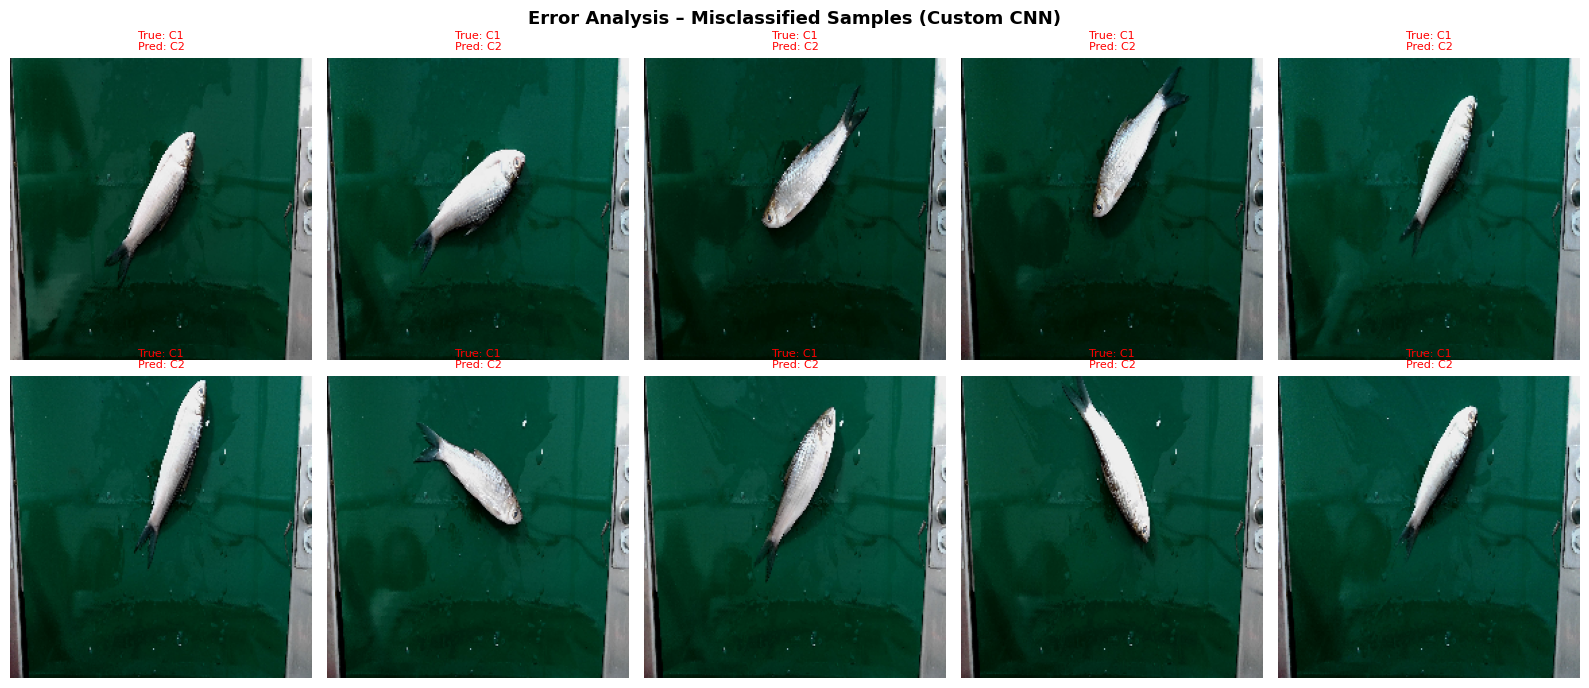

In [16]:
# ── CELL 16 ── Error analysis: misclassified images ──────────
val_gen.reset()
y_pred_cnn  = np.argmax(cnn_model.predict(val_gen, verbose=0), axis=1)
y_true_all  = val_gen.classes
val_gen.reset()
all_imgs    = []
for batch in val_gen:
    all_imgs.append(batch[0])
    if len(all_imgs) * BATCH_SIZE >= val_gen.samples:
        break
all_imgs = np.concatenate(all_imgs, axis=0)[:val_gen.samples]

wrong_idx = np.where(y_pred_cnn != y_true_all)[0]
print(f"\nMisclassified images: {len(wrong_idx)} / {val_gen.samples}")

n_show = min(10, len(wrong_idx))
if n_show > 0:
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    for i, ax in enumerate(axes.flat):
        if i >= n_show:
            ax.axis('off'); continue
        idx = wrong_idx[i]
        ax.imshow(all_imgs[idx])
        ax.set_title(
            f'True: {CLASS_LABELS[y_true_all[idx]]}\n'
            f'Pred: {CLASS_LABELS[y_pred_cnn[idx]]}',
            fontsize=8, color='red'
        )
        ax.axis('off')
    plt.suptitle('Error Analysis – Misclassified Samples (Custom CNN)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/error_analysis.png', dpi=150)
    plt.show()

In [17]:
# ── CELL 17 ── Save best model weights ───────────────────────
best_acc_model_name = results_df.iloc[0]['Model']
print(f"\nBest model: {best_acc_model_name}")
print(f"Best accuracy: {results_df.iloc[0]['Val Accuracy (%)']:.2f}%")
cnn_model.save(f'{OUTPUT_DIR}/fish_freshness_custom_cnn.keras')
mv2_model.save(f'{OUTPUT_DIR}/fish_freshness_mobilenetv2.keras')
print("\nModels saved to:", OUTPUT_DIR)


Best model: MobileNetV2
Best accuracy: 69.58%

Models saved to: /kaggle/working/outputs


In [18]:
# ── CELL 18 ── Final summary ─────────────────────────────────
print("\n" + "="*55)
print("  FINAL RESULTS SUMMARY")
print("="*55)
print(results_df[['Model', 'Val Accuracy (%)', 'Val Loss']].to_string(index=False))
print(f"\nAll output files saved to: {OUTPUT_DIR}")
print("\nFiles generated:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  • {f}")
print("\n✅ Fish Freshness CNN project complete!")


  FINAL RESULTS SUMMARY
                 Model  Val Accuracy (%)  Val Loss
           MobileNetV2             69.58  0.679387
                 VGG16             67.08  1.014669
MobileNetV2 Fine-Tuned             40.83  1.099359
            Custom CNN             33.33  1.127836

All output files saved to: /kaggle/working/outputs

Files generated:
  • best_cnn_model.keras
  • best_mv2_model.keras
  • best_vgg_model.keras
  • class_distribution.png
  • custom_cnn_confusion_matrix.png
  • custom_cnn_curves.png
  • custom_cnn_report.csv
  • custom_cnn_roc.png
  • error_analysis.png
  • fish_freshness_custom_cnn.keras
  • fish_freshness_mobilenetv2.keras
  • gradcam_custom_cnn.png
  • mobilenetv2_confusion_matrix.png
  • mobilenetv2_curves.png
  • mobilenetv2_fine-tuned_curves.png
  • mobilenetv2_fine-tuned_roc.png
  • mobilenetv2_finetuned_confusion_matrix.png
  • mobilenetv2_finetuned_report.csv
  • mobilenetv2_report.csv
  • mobilenetv2_roc.png
  • model_comparison.csv
  • model_compari